<a href="https://colab.research.google.com/github/indra1236/indra/blob/main/Pengolahan_citra_digital_tugas%20pertemuan%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.low-pass filter

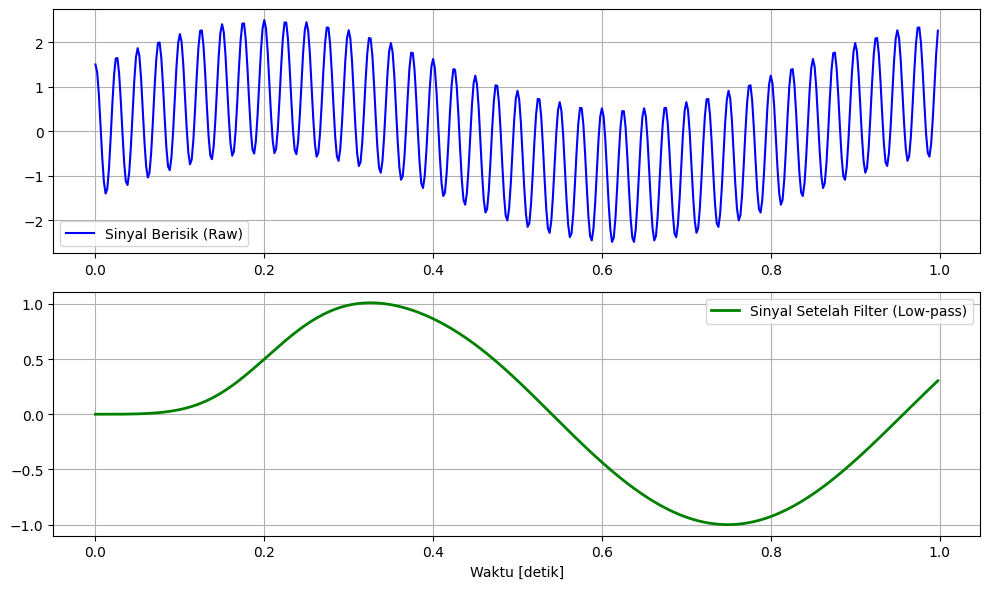

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz

def butter_lowpass(cutoff, fs, order=5):
    """Fungsi untuk mendefinisikan parameter filter."""
    nyq = 0.5 * fs  # Frekuensi Nyquist
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    """Fungsi untuk menerapkan filter pada data."""
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

# --- Simulasi Penggunaan ---

# 1. Parameter Sinyal
fs = 500.0       # Sample rate (Hz)
cutoff = 5.0     # Frekuensi batas yang diinginkan (Hz)
T = 1.0          # Durasi (detik)
n = int(T * fs)  # Jumlah sampel
t = np.linspace(0, T, n, endpoint=False)

# 2. Membuat Sinyal: Campuran Sinyal 1.2Hz dan "Noise" 40Hz
# Kita ingin membuang gelombang 40Hz
data = np.sin(1.2 * 2 * np.pi * t) + 1.5 * np.cos(40 * 2 * np.pi * t)

# 3. Terapkan Filter
y = lowpass_filter(data, cutoff, fs, order=6)

# 4. Visualisasi
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, data, 'b-', label='Sinyal Berisik (Raw)')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, y, 'g-', linewidth=2, label='Sinyal Setelah Filter (Low-pass)')
plt.xlabel('Waktu [detik]')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

2.high-pass filter

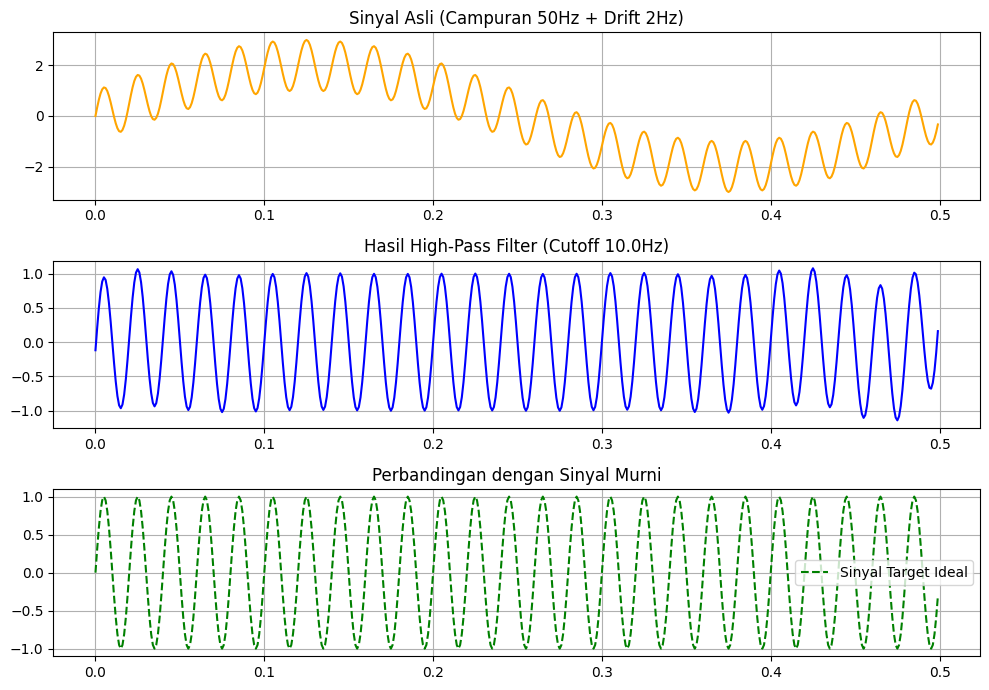

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def butter_highpass(cutoff, fs, order=5):
    """Mendefinisikan koefisien filter high-pass."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    # btype='high' adalah kunci utama di sini
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def highpass_filter(data, cutoff, fs, order=5):
    """Menerapkan filter pada data."""
    b, a = butter_highpass(cutoff, fs, order=order)
    # Menggunakan filtfilt agar tidak ada pergeseran fase (zero-phase filtering)
    y = filtfilt(b, a, data)
    return y

# --- Simulasi Penggunaan ---

fs = 1000.0       # Frekuensi sampling (Hz)
cutoff = 10.0     # Batas frekuensi bawah (Hz)
T = 0.5           # Durasi (detik)
t = np.linspace(0, T, int(T * fs), endpoint=False)

# Membuat sinyal:
# Sinyal 50Hz (yang ingin kita ambil) + Offset Lambat 2Hz (yang ingin dibuang)
sinyal_cepat = np.sin(50 * 2 * np.pi * t)
noise_lambat = 2.0 * np.sin(2 * 2 * np.pi * t)  # Ini dianggap gangguan
data = sinyal_cepat + noise_lambat

# Terapkan High-Pass Filter
data_filtered = highpass_filter(data, cutoff, fs, order=5)

# --- Visualisasi ---
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(t, data, color='orange')
plt.title("Sinyal Asli (Campuran 50Hz + Drift 2Hz)")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, data_filtered, color='blue')
plt.title(f"Hasil High-Pass Filter (Cutoff {cutoff}Hz)")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, sinyal_cepat, 'g--', label='Sinyal Target Ideal')
plt.title("Perbandingan dengan Sinyal Murni")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

3.band-pass filter

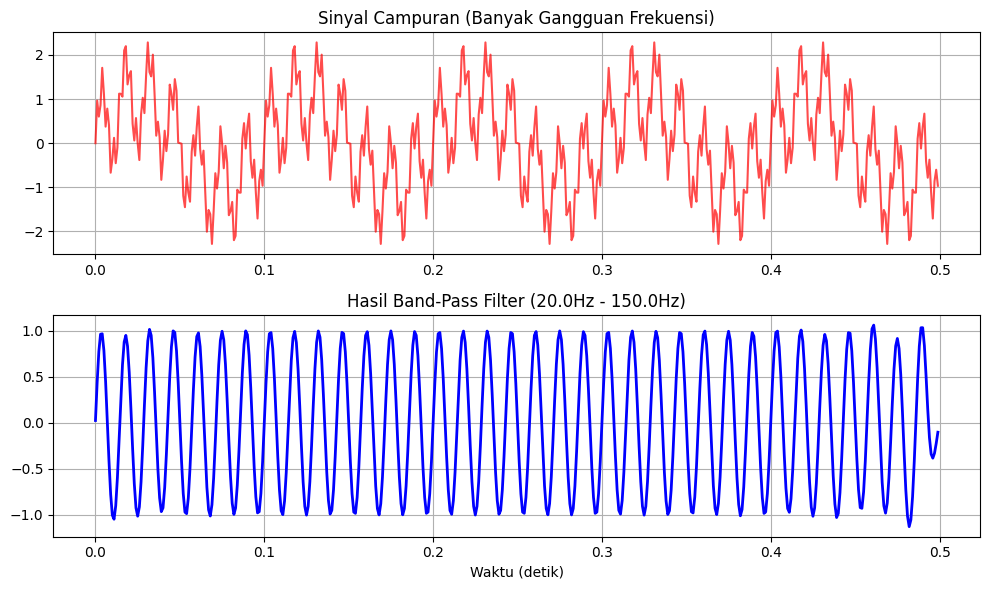

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=5):
    """Mendefinisikan batas bawah dan atas filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # btype='band' digunakan untuk band-pass
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Menerapkan filter band-pass pada data."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

# --- Simulasi Penggunaan ---

fs = 1000.0       # Frekuensi sampling (Hz)
lowcut = 20.0     # Batas bawah (Hz)
highcut = 150.0   # Batas atas (Hz)

T = 0.5
t = np.linspace(0, T, int(T * fs), endpoint=False)

# Membuat sinyal campuran:
# 10Hz (Terlalu rendah), 70Hz (Target), 300Hz (Terlalu tinggi)
s1 = np.sin(10 * 2 * np.pi * t)
s2 = np.sin(70 * 2 * np.pi * t)  # Ini yang ingin kita ambil
s3 = 0.5 * np.sin(300 * 2 * np.pi * t)
data = s1 + s2 + s3

# Terapkan Band-Pass Filter
data_filtered = bandpass_filter(data, lowcut, highcut, fs, order=6)

# --- Visualisasi ---
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, data, color='red', alpha=0.7)
plt.title("Sinyal Campuran (Banyak Gangguan Frekuensi)")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, data_filtered, color='blue', linewidth=2)
plt.title(f"Hasil Band-Pass Filter ({lowcut}Hz - {highcut}Hz)")
plt.xlabel("Waktu (detik)")
plt.grid(True)

plt.tight_layout()
plt.show()

Judul: Noise Removal of ECG Signal usingLow Pass Filter and High Pass Filter

Penulis : S. S. Choudhary, P. Singh

Tahun : 2017